In [1]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
#building dataset

block_size = 3 #context length
X,Y = [],[]
for w in words :
   #print(w)
   context = [0] * block_size
   for ch in w + '.' :
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print (''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)



In [5]:
C = torch.randn((27,2))

In [6]:
emb = C[X]

In [7]:
C[X][13,2]

tensor([-0.6809,  0.7693])

In [8]:
C[1]

tensor([-0.6809,  0.7693])

In [9]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

In [11]:
h

tensor([[ 0.3424, -0.8320, -0.8665,  ...,  0.7171,  1.0000, -0.9589],
        [-0.9918, -0.9998,  0.9156,  ...,  0.9996,  0.9912, -0.9910],
        [-1.0000,  0.7652,  0.9967,  ..., -0.9142, -0.9986,  0.9994],
        ...,
        [ 0.9806, -0.8811,  0.5497,  ...,  0.7870, -0.3429, -0.6234],
        [ 0.9860, -0.0792,  0.9518,  ..., -0.8610, -0.8034,  0.6466],
        [-0.8628,  0.8735,  0.9922,  ..., -0.9439, -0.9930,  0.9951]])

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
w2 = torch.randn([100,27])
b2 = torch.randn(27)

In [14]:
logits = h @ w2 + b2

In [15]:
logits.shape

torch.Size([228146, 27])

In [16]:
logits

tensor([[ 12.7515,  -4.8117,  -5.9822,  ...,   2.1527,   3.2914, -14.6727],
        [  5.5039,   6.2386,  -4.2519,  ...,  -4.2158, -10.7614,  -8.0910],
        [ -3.5680,  -3.9549,  -4.3866,  ...,   3.3485, -13.1507, -14.7097],
        ...,
        [ -9.1063,   6.5386,  12.9903,  ...,  -0.2648,  -3.0156,   2.6465],
        [ -6.1812,  -5.5859,   9.1395,  ...,   2.7927,  -7.4978,  11.1719],
        [ -9.5034,  -5.0093,   4.8546,  ..., -10.0129, -11.8773,  13.8214]])

In [18]:
counts = logits.exp()

In [19]:
prob = counts/counts.sum(1, keepdims=True)

In [20]:
prob.shape

torch.Size([228146, 27])

In [21]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [22]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [23]:
loss = -prob[torch.arange(32), Y[:32]].log().mean()


In [24]:
loss

tensor(15.7809)

In [25]:
F.cross_entropy(logits, Y)

tensor(16.9270)

In [76]:
def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182424, 3]) torch.Size([182424])
torch.Size([22836, 3]) torch.Size([22836])
torch.Size([22886, 3]) torch.Size([22886])


In [75]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


In [69]:
lrc = torch.linspace(-3, 0, 1000)
lrs = 10 ** lrc

In [70]:
lri = []
lossi = []
stepi = []

In [77]:
for i in range(10000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  # lri.append(lrc[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())


3.0233559608459473


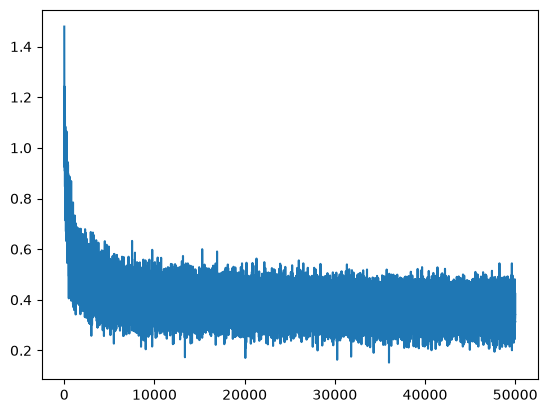

In [66]:
plt.plot(stepi, lossi)

In [67]:
emb = C[Xdev]
h=torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3277, grad_fn=<NllLossBackward0>)

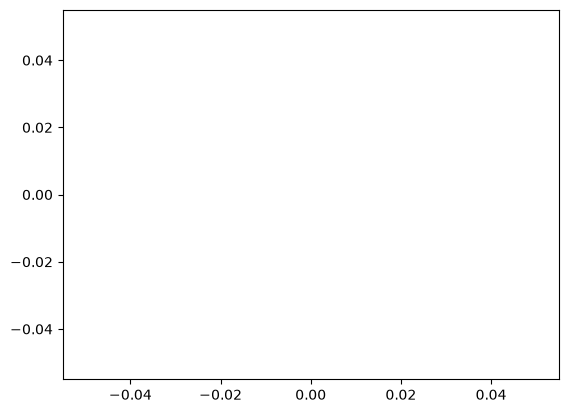

In [31]:
plt.plot(lri,lossi)

In [52]:
torch.randint(0, X.shape[0], (32,))


tensor([221224,  18220,  34794,  63397, 159875, 212776, 137406,  84114, 194658,
        131095,  30212,  46562, 124554, 143503, 157246, 224444, 166144,  87580,
        131951,  86769, 146658, 206230,  48184, 192685,  89830,  48856, 182723,
         92824, 201014,  32876, 144350, 214895])